# Laboratorio 1: Series de Tiempo
**CC3084 - Data Science | UVG | Semestre II 2026**

Análisis del ingreso de viajeros internacionales a Guatemala (2009 - jun 2026).

Integrantes: Iris Ayala 23960, Jonathan Díaz 23837 y Anggie Quezada 23643

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.rcParams['figure.figsize'] = (11, 4)
pd.set_option('display.max_columns', None)

#### cargar datos

In [4]:
df = pd.read_excel('Laboratorio 1. Series de Tiempo 2026 - Base_Migracion_2009-2026jun.xlsx', sheet_name='Datos')
df['Fecha'] = pd.to_datetime(df['Año'].astype(str) + '-' + df['Mes cod'].astype(str) + '-01')
print(df.shape)
df.head()

(161036, 14)


,Año,Mes cod,Mes,Vía,Frontera,País,Región,Región dos,Regiones OMT,MCEO,Agrupación Residencia,Tipo de Viajero,Viajero,Fecha
0,2009,1,Ene,Aérea,01 La Aurora,Albania,OTROS EUROPEOS,Europa,EUROPA MERIDIONAL,08 OTROS,Europa,Turista,1.0,2009-01-01
1,2009,1,Ene,Aérea,01 La Aurora,Alemania,EUROPA,Europa,EUROPA OCCIDENTAL,04 EUROPA,Europa,Turista,716.0,2009-01-01
2,2009,1,Ene,Aérea,01 La Aurora,Angola,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA CENTRAL,08 OTROS,Resto del Mundo,Turista,4.0,2009-01-01
3,2009,1,Ene,Aérea,01 La Aurora,Arabia Saudita,OTROS ORIENTE MEDIO,Oriente Medio,ORIENTE MEDIO,08 OTROS,Resto del Mundo,Turista,5.0,2009-01-01
4,2009,1,Ene,Aérea,01 La Aurora,Argelia,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA DEL NORTE,08 OTROS,Resto del Mundo,Turista,1.0,2009-01-01


### Análisis exploratorio 

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 161036 entries, 0 to 161035
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Año                    161036 non-null  int64         
 1   Mes cod                161036 non-null  int64         
 2   Mes                    161036 non-null  str           
 3   Vía                    161036 non-null  str           
 4   Frontera               161036 non-null  str           
 5   País                   161036 non-null  str           
 6   Región                 161036 non-null  str           
 7   Región dos             161036 non-null  str           
 8   Regiones OMT           161036 non-null  str           
 9   MCEO                   161036 non-null  str           
 10  Agrupación Residencia  161036 non-null  str           
 11  Tipo de Viajero        161036 non-null  str           
 12  Viajero                161036 non-null  float64       


In [6]:
df.describe(include='all').T


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Año,161036.0,NaN,NaN,NaN,2016.017543,2009.0,2012.0,2016.0,2019.0,2026.0,4.552887
Mes cod,161036.0,NaN,NaN,NaN,6.416075,1.0,3.0,6.0,10.0,12.0,3.531936
Mes,161036,12,Ene,14726,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Vía,161036,3,Terrestre,125873,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Frontera,161036,22,01 La Aurora,21424,NaN,NaN,NaN,NaN,NaN,NaN,NaN
País,161036,235,Guatemala,6319,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Región,161036,17,EUROPA,32331,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Región dos,161036,11,Europa,54640,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Regiones OMT,161036,26,AMÉRICA CENTRAL,31362,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MCEO,161036,8,08 OTROS,73173,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Comportamiento temporal del número de viajeros

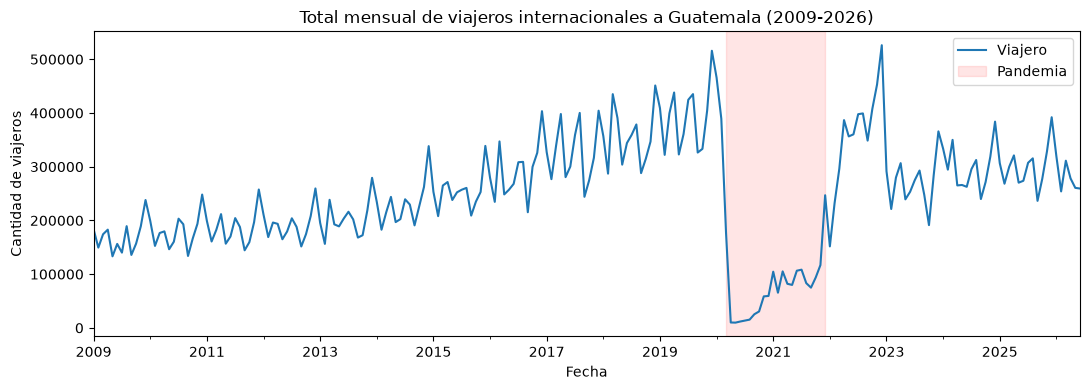

In [7]:
serie_total = df.groupby('Fecha')['Viajero'].sum().sort_index()

fig, ax = plt.subplots()
serie_total.plot(ax=ax)
ax.set_title('Total mensual de viajeros internacionales a Guatemala (2009-2026)')
ax.set_xlabel('Fecha')
ax.set_ylabel('Cantidad de viajeros')
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-12-01'), color='red', alpha=0.1, label='Pandemia')
ax.legend()
plt.tight_layout()
plt.show()


Se ve una tendencia creciente desde 2009 hasta 2019. Después hay una caída bien fuerte
en marzo de 2020, que es cuando cerraron fronteras por la pandemia. Se mantiene bajo como
un año y medio y luego empieza a recuperarse en 2022. También se nota un cambio de nivel
entre 2022 y 2023.

#### mayor cantidad de viajeros

In [8]:
top_paises = df.groupby('País')['Viajero'].sum().sort_values(ascending=False).head(10)
top_paises


País
El Salvador                  1.621398e+07
Guatemala                    1.479233e+07
Estados Unidos de América    7.047843e+06
Honduras                     2.788233e+06
México                       1.808946e+06
Belice                       1.328256e+06
Nicaragua                    1.164343e+06
Cruceristas                  1.078372e+06
Costa Rica                   8.821797e+05
Colombia                     5.610353e+05
Name: Viajero, dtype: float64

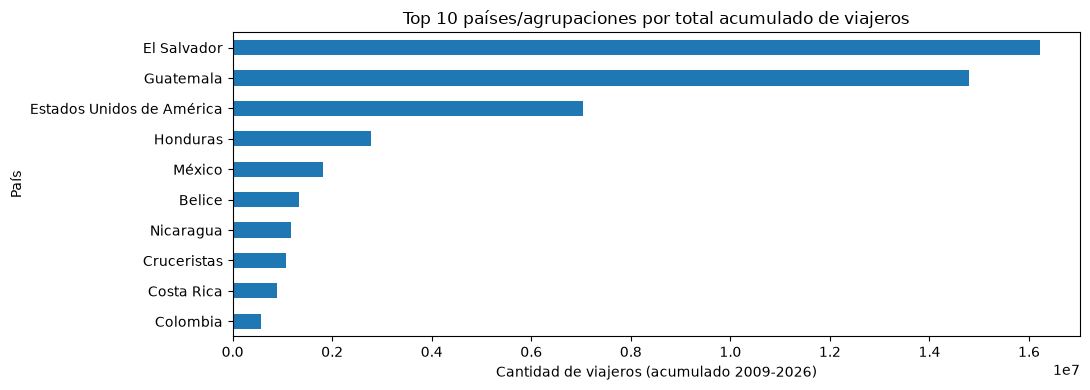

In [9]:
fig, ax = plt.subplots()
top_paises.sort_values().plot(kind='barh', ax=ax)
ax.set_title('Top 10 países/agrupaciones por total acumulado de viajeros')
ax.set_xlabel('Cantidad de viajeros (acumulado 2009-2026)')
plt.tight_layout()
plt.show()

El Salvador y Guatemala son los que más viajeros aportan, seguidos de Estados Unidos, Honduras y México. Con esto queda claro que la mayoría del movimiento es centroamericano y no tanto turismo internacional de otros continentes. Ojo que desde 2023 ya no se reporta cada país individual sino agrupaciones de mercado, entonces comparar país por país antes y después de 2023 hay que hacerlo con cuidado.


#### Regiones con mayor cantidad de viajeros

In [10]:
top_regiones = df.groupby('Región dos')['Viajero'].sum().sort_values(ascending=False)
top_regiones

Región dos
América Del Centro             3.740653e+07
América Del Norte              9.383035e+06
Europa                         2.222621e+06
América Del Sur y el Caribe    1.447950e+06
Cruceristas                    1.078372e+06
Asia                           4.217025e+05
Oceanía                        1.400472e+05
Oriente Medio                  1.357125e+05
Cruceros                       2.603000e+04
Otros Paises Del Mundo         2.511115e+04
0                              8.210000e+02
Name: Viajero, dtype: float64

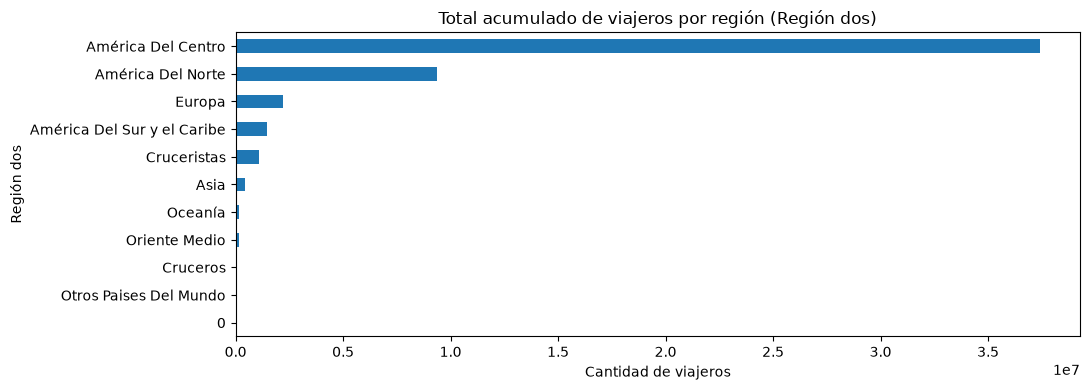

In [11]:
fig, ax = plt.subplots()
top_regiones.sort_values().plot(kind='barh', ax=ax)
ax.set_title('Total acumulado de viajeros por región (Región dos)')
ax.set_xlabel('Cantidad de viajeros')
plt.tight_layout()
plt.show()

América del Centro es la región que más aporta, muy por encima de las demás, luego
América del Norte y después Europa. Esto va de la mano con lo que vimos en países: el
grueso de los viajeros es movimiento regional, no turismo de larga distancia. Hay dos
categorías rarísimas  que casi no pesan nada en el total, seguro son
registros mal clasificados pero no cambian las conclusiones.


#### Vías de ingreso y fronteras más utilizadas

In [12]:
via_totales = df.groupby('Vía')['Viajero'].sum().sort_values(ascending=False)
frontera_totales = df.groupby('Frontera')['Viajero'].sum().sort_values(ascending=False).head(10)
print(via_totales)
print()
print(frontera_totales)


Vía
Terrestre    3.199530e+07
Aérea        1.906385e+07
Marítima     1.228782e+06
Name: Viajero, dtype: float64

Frontera
01 La Aurora                     1.903440e+07
07 Valle Nuevo                   1.073234e+07
09 San Cristóbal                 5.363009e+06
08 Pedro de Alvarado             4.393577e+06
10 La Ermita (Nueva Anguiatú)    2.879210e+06
20 Melchor de Mencos             2.349551e+06
13 El Cinchado / El Corinto      1.497006e+06
12 El Florido                    1.221040e+06
11 Agua Caliente                 1.154542e+06
15 El Carmen                     1.023092e+06
Name: Viajero, dtype: float64


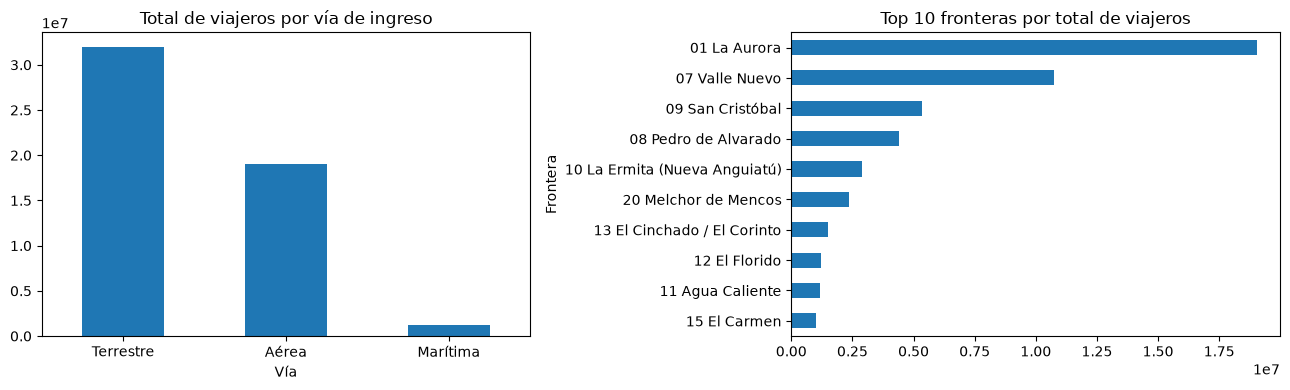

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
via_totales.plot(kind='bar', ax=axes[0])
axes[0].set_title('Total de viajeros por vía de ingreso')
axes[0].tick_params(axis='x', rotation=0)

frontera_totales.sort_values().plot(kind='barh', ax=axes[1])
axes[1].set_title('Top 10 fronteras por total de viajeros')
plt.tight_layout()
plt.show()

La vía Terrestre es la que más se usa por mucho, lo cual tiene sentido porque coincide
con que El Salvador, Honduras y México son los países con más movimiento. La vía Aérea es
la segunda y la Marítima es la que menos se usa. En fronteras, "01 La Aurora" (el
aeropuerto) y "07 Valle Nuevo" (frontera con El Salvador) son las más usadas.

#### Valores faltantes, duplicados y valores atípicos

In [14]:
print('Valores nulos por columna:')
print(df.isnull().sum())
print()
print('Filas totalmente duplicadas:', df.duplicated().sum())

Valores nulos por columna:
Año                      0
Mes cod                  0
Mes                      0
Vía                      0
Frontera                 0
País                     0
Región                   0
Región dos               0
Regiones OMT             0
MCEO                     0
Agrupación Residencia    0
Tipo de Viajero          0
Viajero                  0
Fecha                    0
dtype: int64

Filas totalmente duplicadas: 0


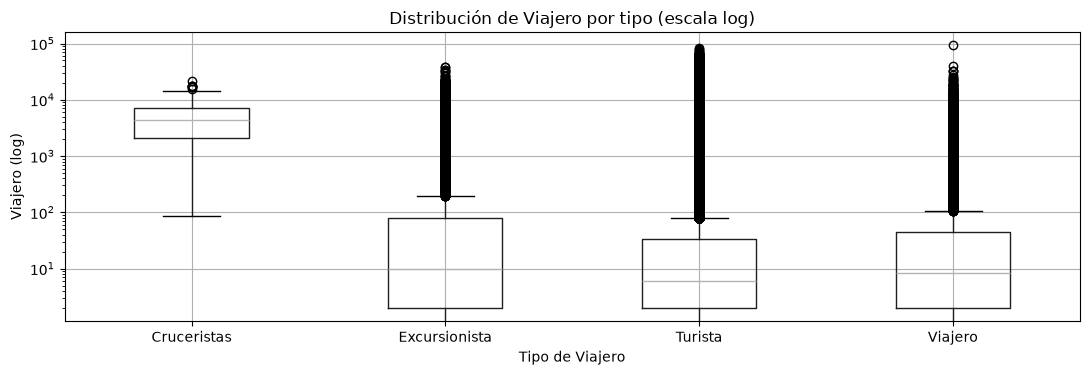

In [15]:
fig, ax = plt.subplots()
df.boxplot(column='Viajero', by='Tipo de Viajero', ax=ax, rot=0)
ax.set_yscale('log')
ax.set_title('Distribución de Viajero por tipo (escala log)')
plt.suptitle('')
ax.set_ylabel('Viajero (log)')
plt.tight_layout()
plt.show()

In [16]:
df['Viajero'].describe()


count    161036.000000
mean        324.697193
std        2387.745140
min           0.000000
25%           2.000000
50%           7.000000
75%          38.891667
max       92336.035067
Name: Viajero, dtype: float64

No hay valores nulos ni filas duplicadas, el dataset ya viene limpio. Sí hay valores
que a simple vista parecen atípicos, como registros de 1 o 2 personas junto a registros de
miles, pero es normal porque se están mezclando países muy distintos en volumen. También
vimos en las notas que algunos valores de Viajero desde 2021 son decimales porque salen de
una estimación de encuesta y no de un conteo exacto, así que esas pequeñas diferencias no
son atípicos reales.


#### estadística descriptiva

In [17]:
resumen_anual = df.groupby('Año')['Viajero'].sum()
resumen_anual


Año
2009    2.028776e+06
2010    2.152899e+06
2011    2.231456e+06
2012    2.299816e+06
2013    2.432169e+06
2014    2.762602e+06
2015    3.041643e+06
2016    3.496217e+06
2017    3.921460e+06
2018    4.256349e+06
2019    4.691820e+06
2020    1.266340e+06
2021    1.267768e+06
2022    4.316164e+06
2023    3.248709e+06
2024    3.593876e+06
2025    3.597238e+06
2026    1.682636e+06
Name: Viajero, dtype: float64

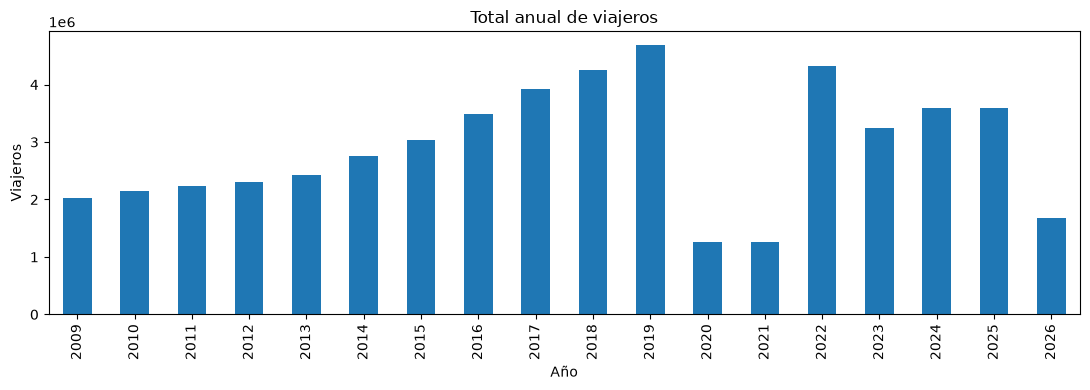

In [18]:
fig, ax = plt.subplots()
resumen_anual.plot(kind='bar', ax=ax)
ax.set_title('Total anual de viajeros')
ax.set_ylabel('Viajeros')
plt.tight_layout()
plt.show()

A nivel anual se ve clarísimo lo que veníamos comentando: la caída de 2020, la
recuperación en 2021-2022, y el salto de nivel en 2023 por el cambio de metodología. Para
comparar años de forma justa en todo el rango conviene usar Turista + Excursionista en vez
del total.

### División en entrenamiento y prueba

Al ser una serie de tiempo no podemos dividir aleatorio, hay que respetar el orden en el
tiempo. Usamos el primer 70% de los meses para entrenamiento y el 30% final para prueba.


In [19]:
meses = serie_total.index.sort_values()
n_train = int(len(meses) * 0.7)
fecha_corte = meses[n_train - 1]

print('Total de meses:', len(meses))
print('Meses de entrenamiento:', n_train, '-> hasta', fecha_corte.strftime('%Y-%m'))
print('Meses de prueba:', len(meses) - n_train, '-> desde', meses[n_train].strftime('%Y-%m'), 'hasta', meses[-1].strftime('%Y-%m'))

df_train = df[df['Fecha'] <= fecha_corte].copy()
df_test  = df[df['Fecha']  > fecha_corte].copy()
print(df_train.shape, df_test.shape)

Total de meses: 210
Meses de entrenamiento: 147 -> hasta 2021-03
Meses de prueba: 63 -> desde 2021-04 hasta 2026-06
(131442, 14) (29594, 14)


### construcción de series de tiempo mensuales (con datos de entrenamiento)

Las categorías que elegimos como grupo son: vías de ingreso, fronteras (top 3) y países
de residencia (top 3). El top 3 de fronteras y países lo sacamos del acumulado dentro del
set de entrenamiento, no de un año en específico.

In [20]:
# Serie obligatoria: total mensual
serie_total_train = df_train.groupby('Fecha')['Viajero'].sum().sort_index()
serie_total_train.head()


Fecha
2009-01-01    183505.590535
2009-02-01    149426.253908
2009-03-01    174237.227095
2009-04-01    182842.489917
2009-05-01    133194.667651
Name: Viajero, dtype: float64

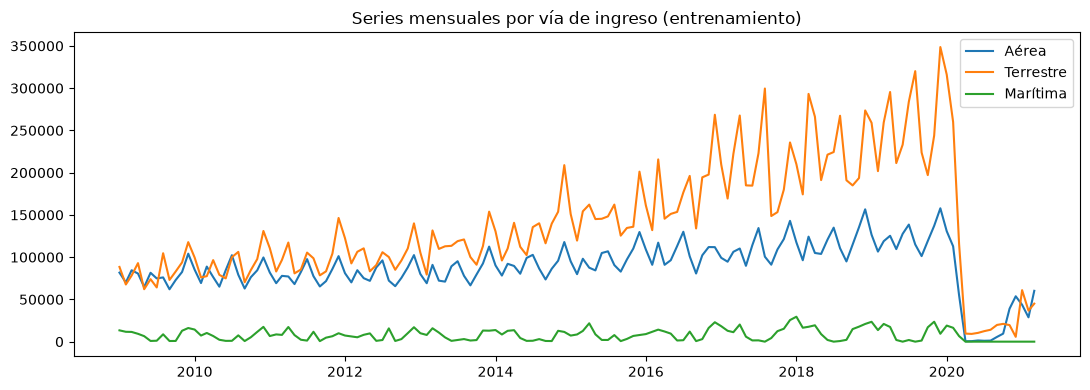

In [21]:
# iii Vías de ingreso: Aérea, Terrestre, Marítima
series_via = {}
for via in ['Aérea', 'Terrestre', 'Marítima']:
    series_via[via] = (df_train[df_train['Vía'] == via]
                        .groupby('Fecha')['Viajero'].sum()
                        .reindex(serie_total_train.index, fill_value=0))

fig, ax = plt.subplots()
for via, s in series_via.items():
    ax.plot(s.index, s.values, label=via)
ax.set_title('Series mensuales por vía de ingreso (entrenamiento)')
ax.legend()
plt.tight_layout()
plt.show()

Top 3 fronteras: ['01 La Aurora', '07 Valle Nuevo', '09 San Cristóbal']


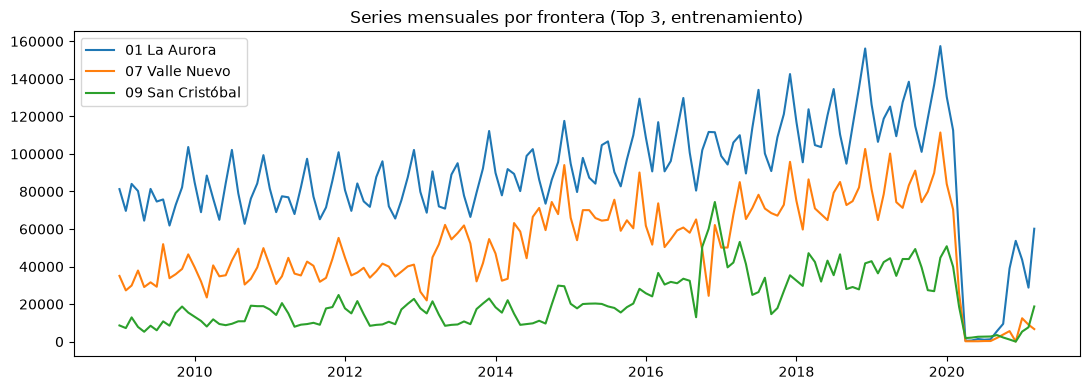

In [22]:
#  Fronteras: Top 3 por acumulado en entrenamiento
top3_fronteras = df_train.groupby('Frontera')['Viajero'].sum().sort_values(ascending=False).head(3).index.tolist()
print('Top 3 fronteras:', top3_fronteras)

series_frontera = {}
for f in top3_fronteras:
    series_frontera[f] = (df_train[df_train['Frontera'] == f]
                           .groupby('Fecha')['Viajero'].sum()
                           .reindex(serie_total_train.index, fill_value=0))

fig, ax = plt.subplots()
for f, s in series_frontera.items():
    ax.plot(s.index, s.values, label=f)
ax.set_title('Series mensuales por frontera (Top 3, entrenamiento)')
ax.legend()
plt.tight_layout()
plt.show()


Top 3 países: ['Guatemala', 'El Salvador', 'Estados Unidos de América']


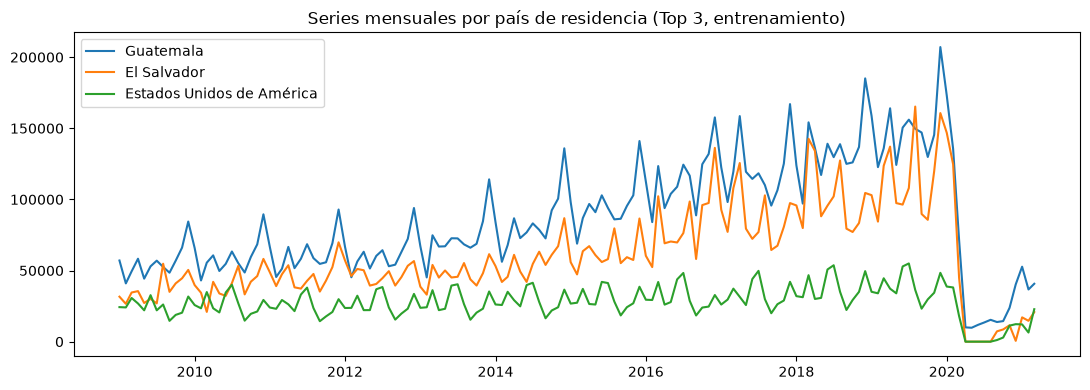

In [23]:
#  Países de residencia: Top 3 por acumulado en entrenamiento
top3_paises = df_train.groupby('País')['Viajero'].sum().sort_values(ascending=False).head(3).index.tolist()
print('Top 3 países:', top3_paises)

series_pais = {}
for p in top3_paises:
    series_pais[p] = (df_train[df_train['País'] == p]
                       .groupby('Fecha')['Viajero'].sum()
                       .reindex(serie_total_train.index, fill_value=0))

fig, ax = plt.subplots()
for p, s in series_pais.items():
    ax.plot(s.index, s.values, label=p)
ax.set_title('Series mensuales por país de residencia (Top 3, entrenamiento)')
ax.legend()
plt.tight_layout()
plt.show()


### Análisis de cada serie

Para el avance de hoy hacemos el análisis completo (incisos a-e) de dos series: el total
mensual y la vía Aérea. Las demás series (Terrestre, Marítima, las 3 fronteras y los 3
países) se analizan igual con la función analizar_serie, y las completamos para la entrega
final del 26 junto con los modelos.

In [24]:
def analizar_serie(serie, nombre, periodo=12):
    print(f'--- {nombre} ---')
    print('Inicio:', serie.index.min().strftime('%Y-%m'))
    print('Fin:', serie.index.max().strftime('%Y-%m'))
    print('Frecuencia: mensual (', len(serie), 'observaciones )')
    print()

    fig, ax = plt.subplots()
    serie.plot(ax=ax)
    ax.set_title(f'Serie mensual: {nombre}')
    plt.tight_layout()
    plt.show()

    try:
        desc = seasonal_decompose(serie, model='additive', period=periodo)
        fig = desc.plot()
        fig.set_size_inches(10, 6)
        fig.suptitle(f'Descomposición aditiva: {nombre}')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print('No se pudo descomponer:', e)

    fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
    plot_acf(serie, ax=axes[0], lags=36)
    plot_pacf(serie, ax=axes[1], lags=36, method='ywm')
    plt.tight_layout()
    plt.show()

    resultado_adf = adfuller(serie.dropna())
    print('ADF statistic:', round(resultado_adf[0], 4))
    print('p-value:', round(resultado_adf[1], 4))
    print('Valores críticos:', resultado_adf[4])
    if resultado_adf[1] < 0.05:
        print('-> Se rechaza H0: la serie es estacionaria en media.')
    else:
        print('-> No se rechaza H0: la serie NO es estacionaria en media (requiere diferenciación).')
    print()
    return desc, resultado_adf

--- Total mensual de viajeros ---
Inicio: 2009-01
Fin: 2021-03
Frecuencia: mensual ( 147 observaciones )



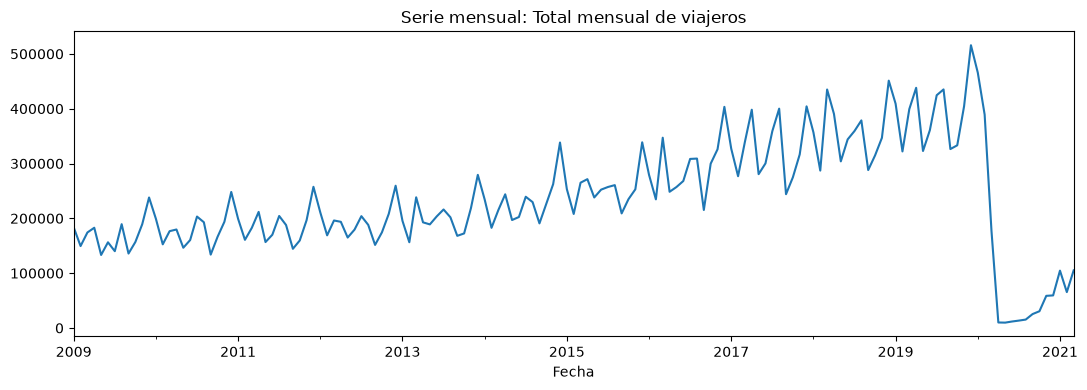

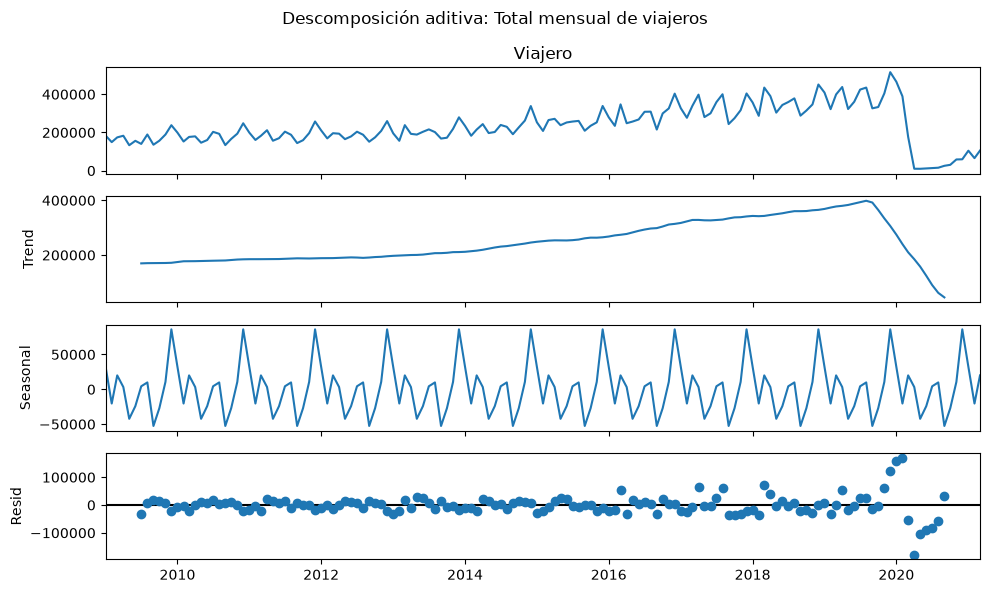

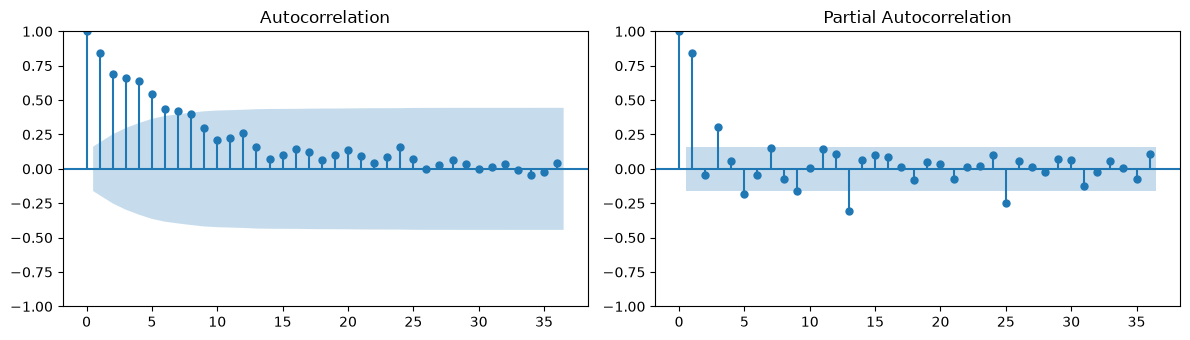

ADF statistic: -1.9701
p-value: 0.2998
Valores críticos: {'1%': np.float64(-3.480118600110386), '5%': np.float64(-2.8833618426136196), '10%': np.float64(-2.578407034974382)}
-> No se rechaza H0: la serie NO es estacionaria en media (requiere diferenciación).



In [25]:
desc_total, adf_total = analizar_serie(serie_total_train, 'Total mensual de viajeros')


Con el total mensual: la gráfica confirma la tendencia de crecimiento hasta 2019, la
caída de la pandemia y la recuperación después, o sea sí hay tendencia. En la
descomposición se ve un patrón que se repite cada 12 meses, así que también hay
estacionalidad (meses de temporada alta y baja de viajes). El residuo se dispara bastante
alrededor de 2020, lo cual tiene sentido porque fue un evento raro y no ruido normal.

En el ACF los valores tardan mucho en bajar a cero, eso es señal de que la serie no es
estacionaria en media. La prueba de Dickey-Fuller lo confirma cuando el p-value sale mayor
a 0.05: en ese caso hay que diferenciar la serie (al menos una diferenciación regular, y
probablemente una estacional de 12 meses) antes de poder ajustar un ARIMA.

--- Vía Aérea ---
Inicio: 2009-01
Fin: 2021-03
Frecuencia: mensual ( 147 observaciones )



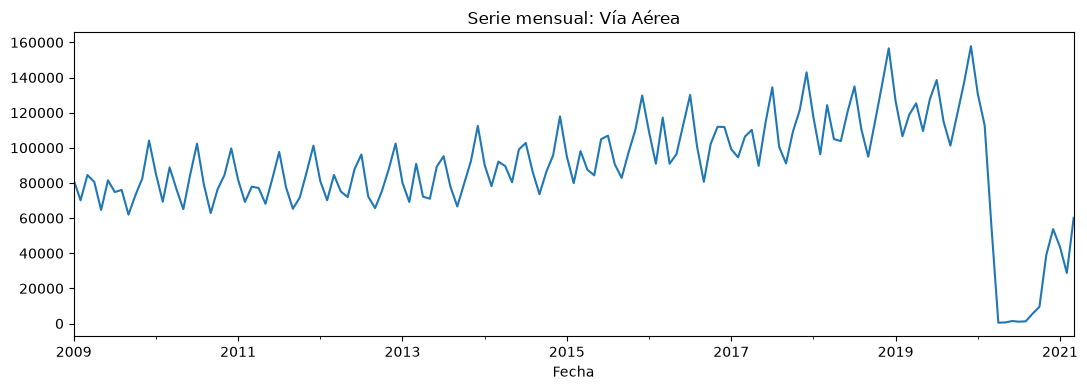

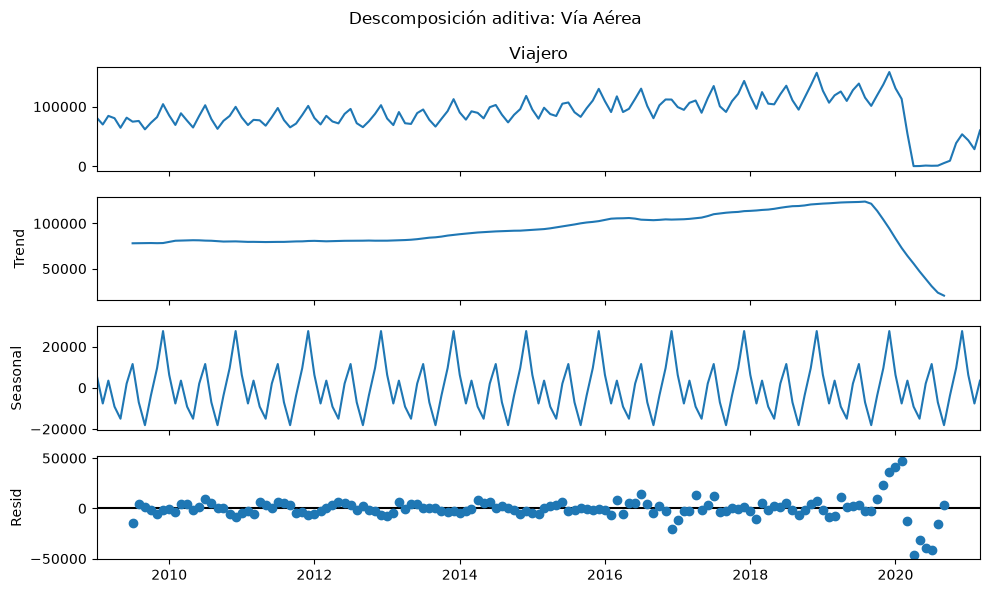

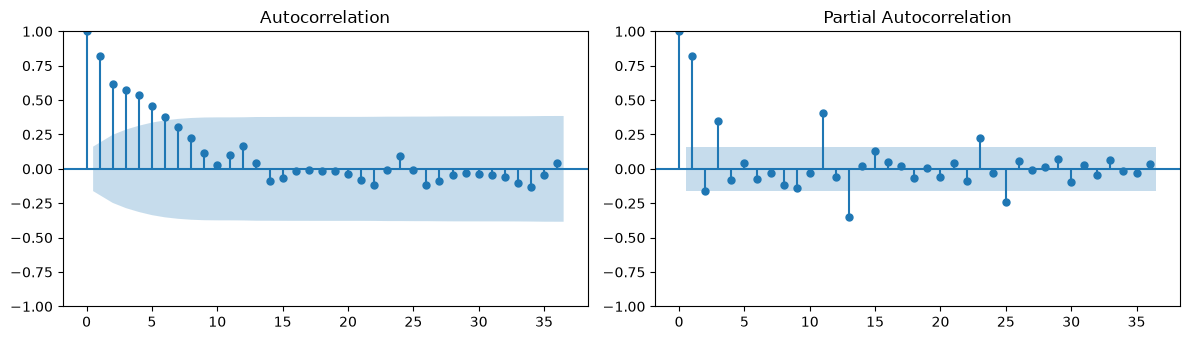

ADF statistic: -2.3637
p-value: 0.1522
Valores críticos: {'1%': np.float64(-3.4808880719210005), '5%': np.float64(-2.8836966192225284), '10%': np.float64(-2.5785857598714417)}
-> No se rechaza H0: la serie NO es estacionaria en media (requiere diferenciación).



In [26]:
desc_aerea, adf_aerea = analizar_serie(series_via['Aérea'], 'Vía Aérea')


Con la vía Aérea: como esta vía es sobre todo turismo internacional, se esperaría una estacionalidad más marcada
por temporadas de viaje, y un golpe todavía más fuerte durante la pandemia porque los
vuelos internacionales se cancelaron casi por completo en 2020. La lectura del ACF y de la
prueba ADF se interpreta igual que en el total: si no se puede rechazar la hipótesis de no
estacionariedad, toca diferenciar antes de modelar.
